#### By: Peyman Shahidi
#### Created: Aug 21, 2026

<br>

Execution mode of the middle step in the local block of Proposition 1, as a function of the predecessor's and the middle step's success probabilities.

manual     optimal on  47.7% of the grid
chain_kn   optimal on  12.7% of the grid
chain_all  optimal on  39.6% of the grid
chain_pk   optimal on   0.0% of the grid


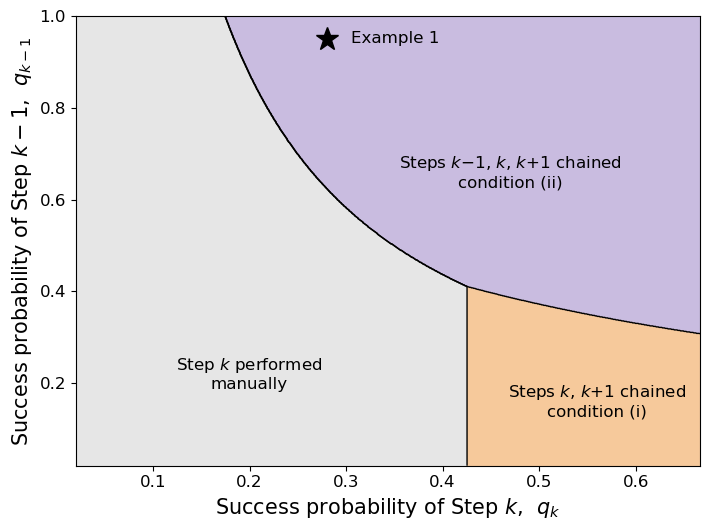

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os

main_folder_path = ".."
output_plot_path = f"{main_folder_path}/writeup/plots"
os.makedirs(output_plot_path, exist_ok=True)

# Which factor performs the middle step k, as a function of the two success
# probabilities q_{k-1} and q_k. Every other parameter is fixed at the values of
# Example 1 of Section 4.1: an expensive but AI-reliable predecessor, an AI-hard
# middle step on which the human holds the comparative advantage throughout the
# figure, and an AI-easy endpoint executed as a standalone augmented step.
tM_p, tA_p = 15.0, 15.0          # step k-1: manual and AI management cost
tM_k, tA_k = 6.0, 4.0            # step k  : manual and AI management cost
tM_n, tA_n, q_n = 8.0, 4.0, 0.9  # step k+1: manual cost, AI management cost, success probability

v_n = min(tM_n, tA_n / q_n)      # standalone cost of the endpoint

# The human holds the comparative advantage on step k whenever tM_k < tA_k / q_k,
# i.e. for q_k below tA_k / tM_k = 2/3, which is where the grid stops.
qk_max = tA_k / tM_k
qk = np.linspace(0.02, qk_max, 900)
qp = np.linspace(0.02, 1.0, 900)
QK, QP = np.meshgrid(qk, qp)

v_p = np.minimum(tM_p, tA_p / QP)                 # standalone cost of the predecessor

cost = {
    "manual":    v_p + tM_k + v_n,                # step k manual, neighbors on their own
    "chain_kn":  v_p + tA_n / (QK * q_n),         # steps k, k+1 chained          -> condition (i)
    "chain_all": tA_n / (QP * QK * q_n),          # steps k-1, k, k+1 chained     -> condition (ii)
    "chain_pk":  tA_k / (QP * QK) + v_n,          # steps k-1, k chained          -> condition (iii)
}
labels = list(cost)
best = np.argmin(np.stack([cost[k] for k in labels]), axis=0)
for i, k in enumerate(labels):
    print(f"{k:10s} optimal on {100*(best == i).mean():5.1f}% of the grid")

colors = ["#e6e6e6", "#f6c99b", "#c9bce0", "#9fc7b0"]
plt.figure(figsize=(7.2, 5.4))
plt.pcolormesh(QK, QP, best, cmap=ListedColormap(colors), vmin=-0.5, vmax=3.5, shading="auto")
plt.contour(QK, QP, best, levels=[0.5, 1.5, 2.5], colors="black", linewidths=1)

plt.text(0.20, 0.22, "Step $k$ performed\nmanually", ha="center", va="center", fontsize=12)
plt.text(0.56, 0.16, "Steps $k$, $k{+}1$ chained\ncondition (i)", ha="center", va="center", fontsize=12)
plt.text(0.47, 0.66, "Steps $k{-}1$, $k$, $k{+}1$ chained\ncondition (ii)", ha="center", va="center", fontsize=12)

plt.plot(0.28, 0.95, marker="*", markersize=17, color="black")
plt.text(0.305, 0.95, "Example 1", fontsize=12, va="center")

plt.xlabel(r"Success probability of Step $k$,  $q_k$", fontsize=15)
plt.ylabel(r"Success probability of Step $k-1$,  $q_{k-1}$", fontsize=15)
plt.xlim(0.02, qk_max)
plt.ylim(0.02, 1.0)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig(f"{output_plot_path}/ca_regions.png", dpi=300)
plt.show()
